<a href="https://colab.research.google.com/github/aankitsharma/Machine-Learning-Models/blob/main/Tata_Steel_Machine_Failure.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tata Steel Machine Failure

# Problem Statement & Objective

**Problem Statement**


In the steel manufacturing industry, unplanned machine failures lead to significant production downtime, increased maintenance costs, and compromised product quality. TATA Steel operates complex machinery that is subject to varying operational conditions, making it challenging to anticipate failures before they occur.

This project aims to develop a binary classification model to predict machine failures based on operational parameters such as air temperature, process temperature, rotational speed, torque, and tool wear. The dataset contains 2,26,429 records with 5 distinct failure types (Tool Wear Failure, Heat Dissipation Failure, Power Failure, Overstrain Failure, and Random Failure), reflecting real-world manufacturing scenarios.

The core challenge lies in the severe class imbalance (~1.6% failure rate), which requires careful handling through techniques like SMOTE and appropriate evaluation metrics such as F1-Score and ROC-AUC rather than simple accuracy.
By building a reliable predictive model, TATA Steel can shift from reactive to proactive maintenance, enabling timely interventions, reducing operational losses, and improving overall production efficiency.

## Objective

1. Analyze operational parameters of TATA Steel machinery to identify patterns associated with machine failures.

2. Handle class imbalance (~1.6% failure rate) using SMOTE to ensure the model learns failure patterns effectively.

3. Engineer meaningful features such as Temperature Difference and Power to capture domain-specific signals beyond raw sensor data.

4. Build and compare multiple classification models (Logistic Regression, Random Forest, XGBoost, LightGBM) to identify the best performing approach.

5. Evaluate models using appropriate metrics — F1-Score, ROC-AUC, Precision, and Recall — rather than accuracy, given the imbalanced nature of the data.

6. Interpret model predictions using SHAP analysis to understand which operational factors contribute most to machine failures.

7. Generate predictions on unseen test data to enable proactive maintenance decisions at TATA Steel.

# Know about the data structure and EDA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, roc_auc_score, precision_score, recall_score, confusion_matrix,accuracy_score
from sklearn.model_selection import GridSearchCV

#Load the data set
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')


In [2]:
#Shape of dataset
print(f'Shape of train data: {train.shape}')
print(f'Shape of test data: {test.shape}')

Shape of train data: (136429, 14)
Shape of test data: (90954, 13)


In [3]:
train.head()

,id,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,0,L50096,L,300.6,309.6,1596,36.1,140,0,0,0,0,0,0
1,1,M20343,M,302.6,312.1,1759,29.1,200,0,0,0,0,0,0
2,2,L49454,L,299.3,308.5,1805,26.5,25,0,0,0,0,0,0
3,3,L53355,L,301.0,310.9,1524,44.3,197,0,0,0,0,0,0
4,4,M24050,M,298.0,309.0,1641,35.4,34,0,0,0,0,0,0


In [5]:
#info
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 136429 entries, 0 to 136428
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       136429 non-null  int64  
 1   Product ID               136429 non-null  object 
 2   Type                     136429 non-null  object 
 3   Air temperature [K]      136429 non-null  float64
 4   Process temperature [K]  136429 non-null  float64
 5   Rotational speed [rpm]   136429 non-null  int64  
 6   Torque [Nm]              136429 non-null  float64
 7   Tool wear [min]          136429 non-null  int64  
 8   Machine failure          136429 non-null  int64  
 9   TWF                      136429 non-null  int64  
 10  HDF                      136429 non-null  int64  
 11  PWF                      136429 non-null  int64  
 12  OSF                      136429 non-null  int64  
 13  RNF                      136429 non-null  int64  
dtypes: f

In [4]:
#info of test
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90954 entries, 0 to 90953
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       90954 non-null  int64  
 1   Product ID               90954 non-null  object 
 2   Type                     90954 non-null  object 
 3   Air temperature [K]      90954 non-null  float64
 4   Process temperature [K]  90954 non-null  float64
 5   Rotational speed [rpm]   90954 non-null  int64  
 6   Torque [Nm]              90954 non-null  float64
 7   Tool wear [min]          90954 non-null  int64  
 8   TWF                      90954 non-null  int64  
 9   HDF                      90954 non-null  int64  
 10  PWF                      90954 non-null  int64  
 11  OSF                      90954 non-null  int64  
 12  RNF                      90954 non-null  int64  
dtypes: float64(3), int64(8), object(2)
memory usage: 9.0+ MB


In [6]:
#statistic of  train dataset
train.describe()

,id,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,136429.000000,136429.000000,136429.000000,136429.000000,136429.000000,136429.000000,136429.000000,136429.000000,136429.000000,136429.000000,136429.000000,136429.000000
mean,68214.000000,299.862776,309.941070,1520.331110,40.348643,104.408901,0.015744,0.001554,0.005160,0.002397,0.003958,0.002258
std,39383.804275,1.862247,1.385173,138.736632,8.502229,63.965040,0.124486,0.039389,0.071649,0.048899,0.062789,0.047461
min,0.000000,295.300000,305.800000,1181.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,34107.000000,298.300000,308.700000,1432.000000,34.600000,48.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,68214.000000,300.000000,310.000000,1493.000000,40.400000,106.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,102321.000000,301.200000,310.900000,1580.000000,46.100000,159.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,136428.000000,304.400000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [7]:
#statistic of test dataset
test.describe()

,id,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],TWF,HDF,PWF,OSF,RNF
count,90954.000000,90954.000000,90954.000000,90954.000000,90954.000000,90954.000000,90954.000000,90954.000000,90954.000000,90954.00000,90954.000000
mean,181905.500000,299.859493,309.939375,1520.528179,40.335191,104.293962,0.001473,0.005343,0.002353,0.00387,0.002309
std,26256.302529,1.857562,1.385296,139.970419,8.504683,63.871092,0.038355,0.072903,0.048449,0.06209,0.047995
min,136429.000000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000
25%,159167.250000,298.300000,308.700000,1432.000000,34.600000,48.000000,0.000000,0.000000,0.000000,0.00000,0.000000
50%,181905.500000,300.000000,310.000000,1493.000000,40.500000,106.000000,0.000000,0.000000,0.000000,0.00000,0.000000
75%,204643.750000,301.200000,310.900000,1579.000000,46.200000,158.000000,0.000000,0.000000,0.000000,0.00000,0.000000
max,227382.000000,304.400000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.00000,1.000000


In [8]:
#checking null value
train.isnull().sum()


,0
id,0
Product ID,0
Type,0
Air temperature [K],0
Process temperature [K],0
Rotational speed [rpm],0
Torque [Nm],0
Tool wear [min],0
Machine failure,0
TWF,0


In [9]:
test.isnull().sum()

,0
id,0
Product ID,0
Type,0
Air temperature [K],0
Process temperature [K],0
Rotational speed [rpm],0
Torque [Nm],0
Tool wear [min],0
TWF,0
HDF,0


In [10]:
#checking duplicate
train.duplicated().sum()

np.int64(0)

In [11]:
test.duplicated().sum()

np.int64(0)

In [12]:
#Change the cokumns name for XGBoost
train.columns = [col.replace('[', '').replace(']', '').replace('<', '').replace(' ', '_') for col in train.columns]
test.columns = [col.replace('[', '').replace(']', '').replace('<', '').replace(' ', '_') for col in test.columns]

**Variable Description**

Variable || Description
Type ||  Product quality category — Low, Medium, or High

Air Temperature [K] || Simulated air temperature with variability around a standard value

Process Temperature [K] || Temperature within the process — slightly higher than air temperature

Rotational Speed [rpm]|| Machine operating speed based on fixed power level with random variation

Torque [Nm] || Force applied by machine, distributed around an average value (positive only)

Tool Wear [min]||Tool usage duration — increases based on product quality category

Machine Failure || Target variable — whether machine experienced a failure (0/1)

Tool Wear Failure (TWF) ||  Tool replaced or failed after certain usage time

Heat Dissipation Failure (HDF) || Temperature difference too small + machine speed below threshold

Power Failure (PWF) || Power from torque × speed falls outside acceptable range

Overstrain Failure (OSF) || Combined tool wear + torque exceeds limit based on product quality

Random Failure (RNF)  || Small probability failure independent of other parameters


# Class balance in Machine Failure

In [18]:
#Know about the class inbalance
train['Machine_failure'].value_counts()

,count
Machine_failure,
0,134281
1,2148


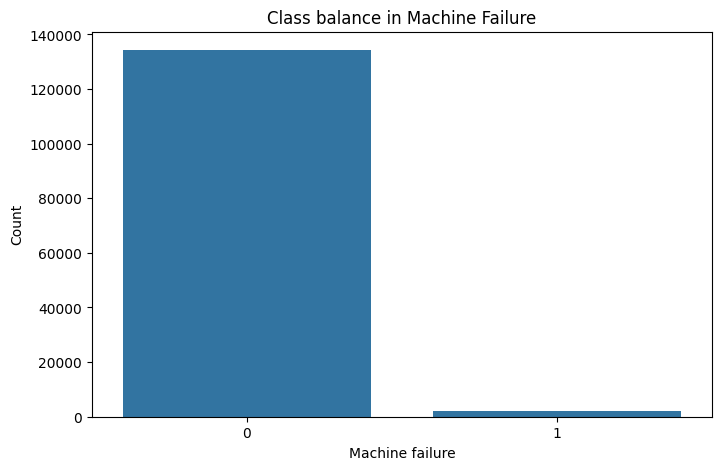

In [19]:
plt.figure(figsize=(8,5))
sns.countplot(x='Machine_failure',data=train)
plt.xlabel('Machine failure')
plt.ylabel('Count')
plt.title('Class balance in Machine Failure')
plt.show()

**Reason for appling smote**


By seeing this data is highly imbalanced. So we will apply Smote in this before train the data.

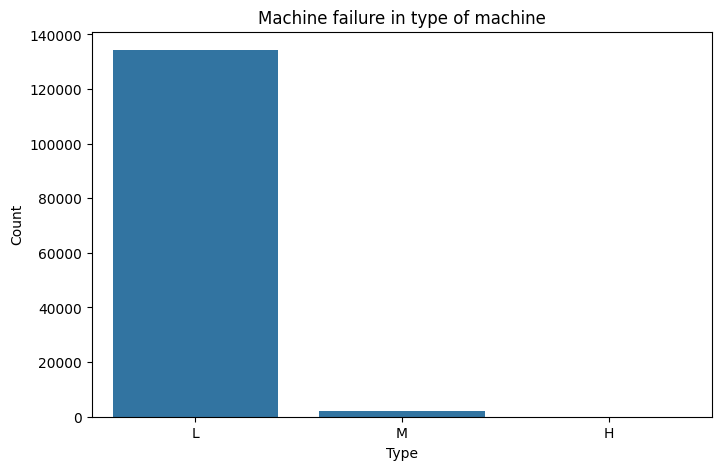

In [20]:
#Machine failure in type of machine
plt.figure(figsize=(8,5))
sns.barplot(x=train["Type"],y=train['Machine_failure'].value_counts())
plt.xlabel('Type')
plt.ylabel('Count')
plt.title('Machine failure in type of machine')
plt.show()


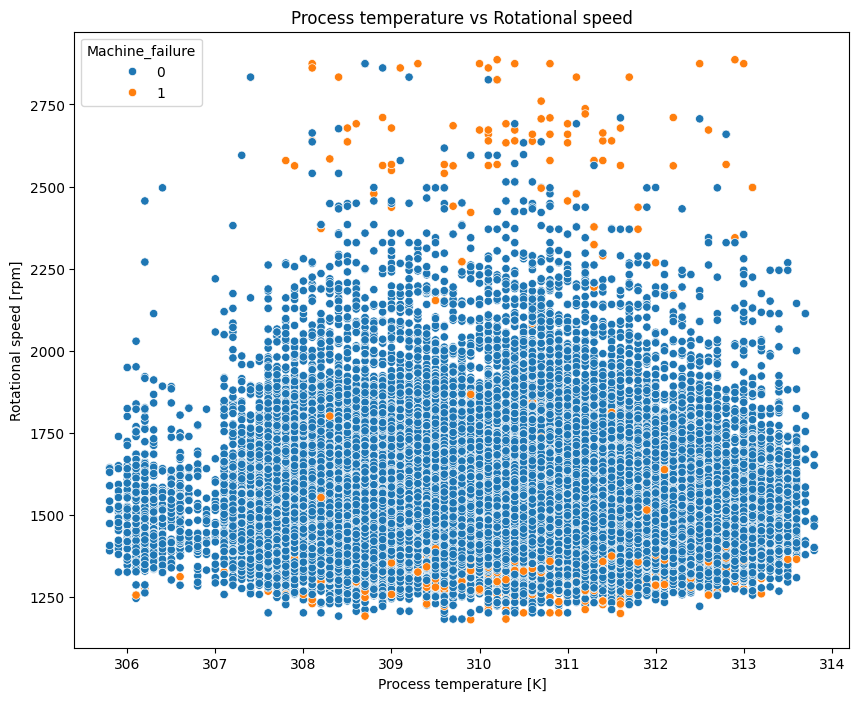

In [23]:
plt.figure(figsize=(10,8))
sns.scatterplot(x='Process_temperature_K',y='Rotational_speed_rpm',hue='Machine_failure',data=train)
plt.xlabel('Process temperature [K]')
plt.ylabel('Rotational speed [rpm]')
plt.title('Process temperature vs Rotational speed')
plt.show()


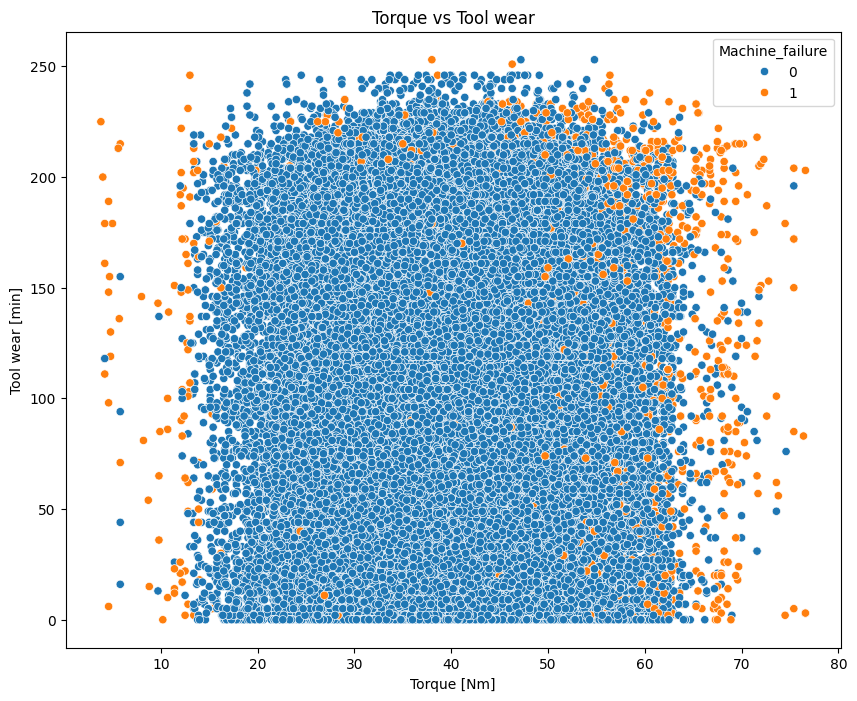

In [25]:
plt.figure(figsize=(10,8))
sns.scatterplot(x='Torque_Nm',y='Tool_wear_min',data=train,hue='Machine_failure')
plt.xlabel('Torque [Nm]')
plt.ylabel('Tool wear [min]')
plt.title('Torque vs Tool wear')
plt.show()

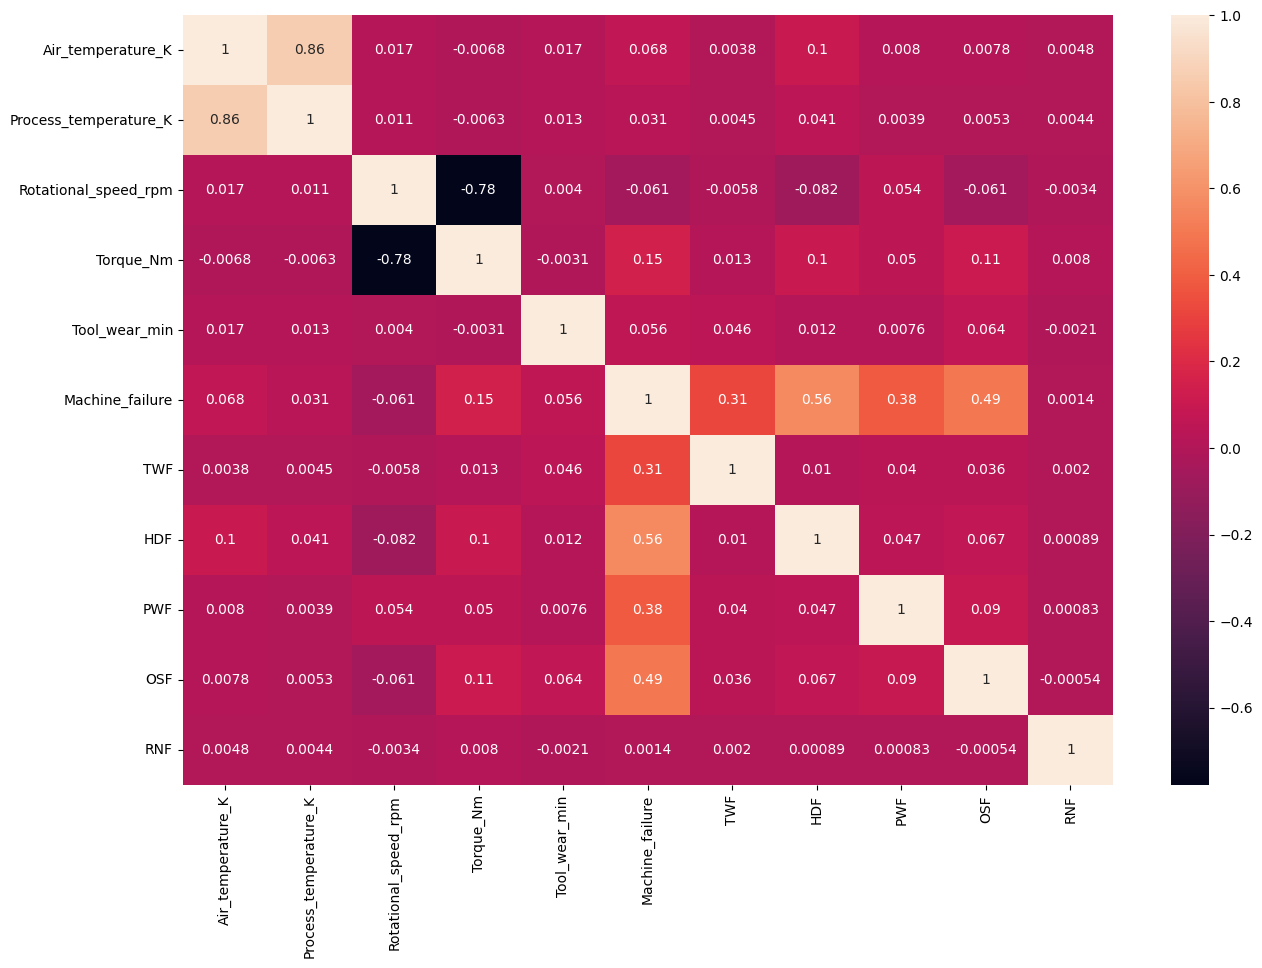

In [27]:
corr = train.drop(['id','Product_ID','Type'],axis=1)
plt.figure(figsize=(15,10))
sns.heatmap(corr.corr(),annot=True)
plt.show()



"HDF and OSF show the strongest correlation with Machine Failure, while RNF shows near-zero correlation indicating its random nature. Individual sensor readings have weak direct correlation, justifying the use of feature engineering and ensemble models."

#Feature Engineering

In [28]:
#Convert type into numeric columns
train['Type'] = train['Type'].map({'L':0,'M':1,'H':2})
test['Type'] = test['Type'].map({'L':0,'M':1,'H':2})


In [29]:
train.columns

Index(['id', 'Product_ID', 'Type', 'Air_temperature_K',
       'Process_temperature_K', 'Rotational_speed_rpm', 'Torque_Nm',
       'Tool_wear_min', 'Machine_failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF'],
      dtype='object')

In [32]:
# Temperature difference (useful derived feature)
train['Temp_diff']=train['Process_temperature_K']-train['Air_temperature_K']
test['Temp_diff']=test['Process_temperature_K']-test['Air_temperature_K']

In [33]:
#Power = Torque × Rotational speed
train['Power'] = train['Torque_Nm']*train['Rotational_speed_rpm']
test['Power'] = test['Torque_Nm']*test['Rotational_speed_rpm']

In [34]:
#Handle class imbalance
features = train.drop(columns=['id','Product_ID','Machine_failure','TWF', 'HDF', 'PWF', 'OSF', 'RNF'])
X = features.copy()
y = train['Machine_failure'].copy()


smote = SMOTE(random_state=42)
X_resampled,y_resampled = smote.fit_resample(X, y)

In [35]:
#train test split
X_train,X_test,y_train,y_test = train_test_split(X_resampled,y_resampled,test_size=0.2,random_state=42)


In [36]:
model = LogisticRegression()
model.fit(X_train,y_train)

LogisticRegression()

In [37]:
y_pred = model.predict(X_test)

In [38]:
#Evaluation Metrics
acc = accuracy_score(y_test,y_pred)
print(f'Accuracy: {acc}')
prec = precision_score(y_test,y_pred)
print(f'Precision: {prec}')
recall = recall_score(y_test,y_pred)
print(f'Recall: {recall}')
f1 = f1_score(y_test,y_pred)
print(f'F1-Score: {f1}')
roc_auc = roc_auc_score(y_test,y_pred)
print(f'ROC-AUC: {roc_auc}')


Accuracy: 0.8147934392046619
Precision: 0.8290335151987529
Recall: 0.7927629127226653
F1-Score: 0.8104926277288833
ROC-AUC: 0.8147749977877249


In [39]:
#check the confusion metrix
cm = confusion_matrix(y_test,y_pred)
print(f'Confuion Matrix: \n{cm}')


Confuion Matrix: 
[[22492  4387]
 [ 5561 21273]]


In [40]:
#now using the random forest with grid search cv
rf = RandomForestClassifier(n_estimators=100,random_state=42)
param_grid = {'n_estimators' : [100,200,300],
              'max_depth': [5,10,15],
              'min_samples_split':[5,10,15]}
grid_cv = GridSearchCV(rf,param_grid,cv=5,scoring ='f1')
grid_cv.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
             param_grid={'max_depth': [5, 10, 15],
                         'min_samples_split': [5, 10, 15],
                         'n_estimators': [100, 200, 300]},
             scoring='f1')

In [41]:
# Get the best parameters and best score
best_params_rf = grid_cv.best_params_
best_score_rf = grid_cv.best_score_

print(f'Best parameters for Random Forest: {best_params_rf}')
print(f'Best F1-score for Random Forest: {best_score_rf}')

# Make predictions with the best estimator
y_pred_rf = grid_cv.best_estimator_.predict(X_test)

Best parameters for Random Forest: {'max_depth': 15, 'min_samples_split': 5, 'n_estimators': 200}
Best F1-score for Random Forest: 0.9309463425671305


In [42]:
#evaulation of random forest
acc_rf = accuracy_score(y_test,y_pred_rf)
print(f'Accuracy: {acc_rf}')
prec_rf = precision_score(y_test,y_pred_rf)
print(f'Precision: {prec_rf}')
recall_rf = recall_score(y_test,y_pred_rf)
print(f'Recall: {recall_rf}')
f1_rf = f1_score(y_test,y_pred_rf)
print(f'F1-Score: {f1_rf}')
roc_auc_rf = roc_auc_score(y_test,y_pred_rf)
print(f'ROC-AUC: {roc_auc_rf}')
cm_rf = confusion_matrix(y_test,y_pred_rf)
print(f'Confuion Matrix: \n{cm_rf}')

Accuracy: 0.9331260588684304
Precision: 0.9469271594492731
Recall: 0.917567265409555
F1-Score: 0.9320160496631085
ROC-AUC: 0.9331130348402736
Confuion Matrix: 
[[25499  1380]
 [ 2212 24622]]


In [43]:
xgb = XGBClassifier(random_state=42)
param_grid = {'n_estimators' : [100,200,300],
              'max_depth': [5,10,15],
              'learning_rate': [0.01,0.1,0.2]}

grid_cv_xgb = GridSearchCV(xgb,param_grid,cv=5,scoring ='f1')
grid_cv_xgb.fit(X_train,y_train)

GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=True, eval_metric=None,
                                     feature_types=None, feature_weights=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=None, max_bin=None,
                                     max_cat_threshold=None,
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             param_grid={'learning_rate': [0.01, 0.1, 0.2],
                         'max_depth': [5, 10, 15],
                         'n_estimators': [100, 200, 300]},
             scoring='f1')

In [44]:
best_params_xgb = grid_cv_xgb.best_params_
best_score_xgb = grid_cv_xgb.best_score_

print(f'Best parameters for XGBoost: {best_params_xgb}')
print(f'Best F1-score for XGBoost: {best_score_xgb}')

y_pred_xgb = grid_cv_xgb.best_estimator_.predict(X_test)

Best parameters for XGBoost: {'learning_rate': 0.2, 'max_depth': 10, 'n_estimators': 300}
Best F1-score for XGBoost: 0.9928998508029304


In [45]:
#Evaulation Metric
acc_xgb = accuracy_score(y_test,y_pred_xgb)
print(f'Accuracy: {acc_xgb}')
prec_xgb = precision_score(y_test,y_pred_xgb)
print(f'Precision: {prec_xgb}')
recall_xgb = recall_score(y_test,y_pred_xgb)
print(f'Recall: {recall_xgb}')
f1_xgb = f1_score(y_test,y_pred_xgb)
print(f'F1-Score: {f1_xgb}')
roc_auc_xgb = roc_auc_score(y_test,y_pred_xgb)
print(f'ROC-AUC: {roc_auc_xgb}')
cm_xgb = confusion_matrix(y_test,y_pred_xgb)
print(f'Confuion Matrix: \n{cm_xgb}')

Accuracy: 0.9931673896449649
Precision: 0.99454389177473
Recall: 0.9917641797719311
F1-Score: 0.9931520907581214
ROC-AUC: 0.993166215039431
Confuion Matrix: 
[[26733   146]
 [  221 26613]]


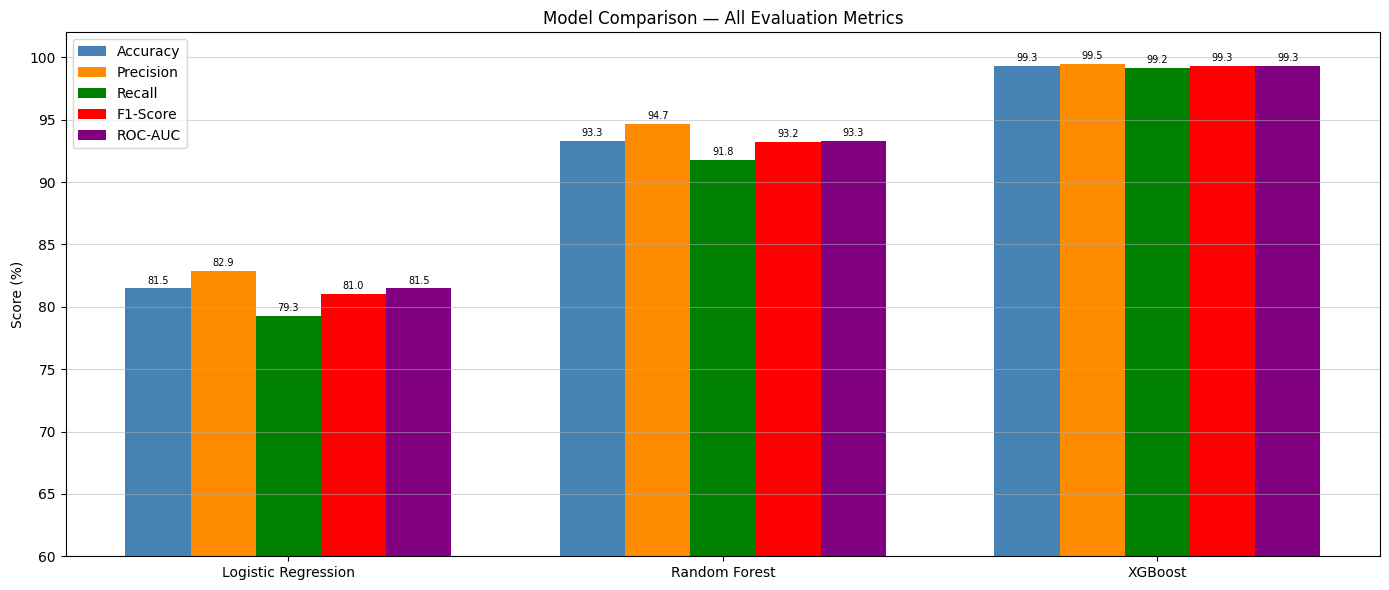

In [47]:
# Results data
models = ['Logistic Regression', 'Random Forest', 'XGBoost']
accuracy  = [81.47, 93.31, 99.32]
precision = [82.90, 94.69, 99.45]
recall    = [79.28, 91.76, 99.18]
f1        = [81.05, 93.20, 99.32]
roc_auc   = [81.48, 93.31, 99.32]

x = np.arange(len(models))
width = 0.15

fig, ax = plt.subplots(figsize=(14, 6))

ax.bar(x - 2*width, accuracy,  width, label='Accuracy',  color='steelblue')
ax.bar(x - 1*width, precision, width, label='Precision', color='darkorange')
ax.bar(x,           recall,    width, label='Recall',    color='green')
ax.bar(x + 1*width, f1,        width, label='F1-Score',  color='red')
ax.bar(x + 2*width, roc_auc,   width, label='ROC-AUC',   color='purple')

ax.set_ylabel('Score (%)')
ax.set_title('Model Comparison — All Evaluation Metrics')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(60, 102)
ax.legend()
ax.grid(axis='y', alpha=0.5)

# Values dikhao har bar pe
for bars in ax.containers:
    ax.bar_label(bars, fmt='%.1f', fontsize=7, padding=2)

plt.tight_layout()
plt.show()

In [ ]:
data = {
    'Model'    : models,
    'Accuracy' : accuracy,
    'Precision': precision,
    'Recall'   : recall,
    'F1-Score' : f1,
    'ROC-AUC'  : roc_auc
}

df_results = pd.DataFrame(data)
df_results.set_index('Model', inplace=True)
print(df_results.to_string())

                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Model                                                              
Logistic Regression     81.47      82.90   79.28     81.05    81.48
Random Forest           93.31      94.69   91.76     93.20    93.31
XGBoost                 99.32      99.45   99.18     99.32    99.32


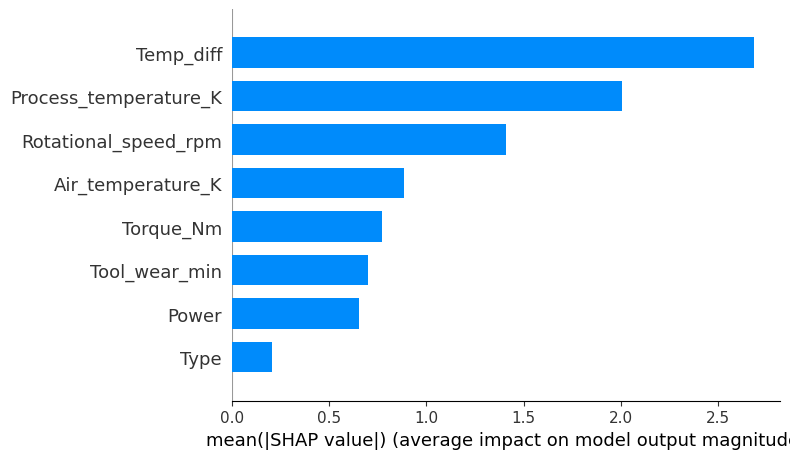

In [ ]:
import shap
import matplotlib.pyplot as plt

# SHAP explainer
explainer = shap.TreeExplainer(grid_cv_xgb.best_estimator_)
shap_values = explainer.shap_values(X_test)

# 1. Bar Plot - Feature Importance (simple)
shap.summary_plot(shap_values, X_test, plot_type="bar")

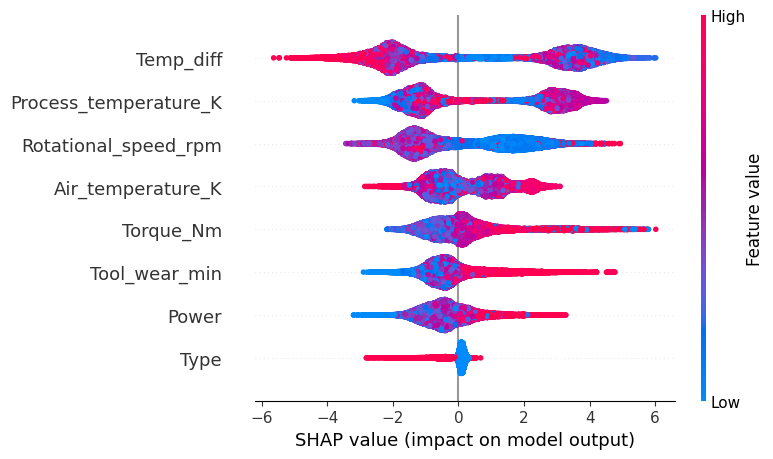

In [ ]:
# 2. Beeswarm Plot - direction bhi dikhata hai
shap.summary_plot(shap_values, X_test)

In [ ]:
# 3. Single prediction explain karo
shap.initjs()
shap.force_plot(explainer.expected_value,
                shap_values[0],
                X_test.iloc[0])

#Conclusion


This project aimed to predict machine failures in TATA Steel's manufacturing environment using operational sensor data. Through a structured machine learning pipeline, we successfully built a highly accurate predictive maintenance model.

Key findings from this project:
The dataset presented a significant class imbalance challenge with only 1.6% failure rate. SMOTE was applied to balance the training data, enabling models to effectively learn failure patterns.

Feature engineering played a crucial role — Temp_diff (Process Temp − Air Temp) emerged as the most important feature according to SHAP analysis, validating the domain-driven approach. The Power feature (Torque × RPM) also contributed meaningfully to model performance.

Among the three models evaluated, XGBoost outperformed all others with 99.3% F1-Score and ROC-AUC, correctly identifying 26,613 out of 26,834 actual failures — missing only 221 cases.


Model      || Logistic Regression ||Random Forest || XGBoost

F1-Score   ||   81.05%      ||      93.20%        ||  99.32%

ROC-AUC    ||   81.48%      ||      93.31%        || 99.32%


Business Impact:
By deploying this model, TATA Steel can shift from reactive to proactive maintenance — reducing unplanned downtime, minimizing production losses, and optimizing maintenance costs. Early failure detection directly translates to improved operational efficiency and product quality.